todos:


1. count sig electrodes not contained in current ROIs
2. brain plots

In [ ]:
import os, argparse, math
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import sys
sys.path.append("/scratch/gpfs/ij9216/projects/code/247/247-plotting/scripts")
from tfsplt_glassbrain import plot_glassbrain
from tfsplt_brainmap import read_coor


# function definitions
def plot_roi(args, df, mode="", ymax=None, save=True, plot_indiv=False):
    mode_full = "Comprehension" if mode == "comp" else "Production"
    n_rois = len(args.rois)
    if not save:
        ncols = 2
        nrows = math.ceil(n_rois / ncols)
        fig, axes = plt.subplots(nrows, ncols, figsize=(10 * ncols, 5 * nrows))
        axes = axes.flatten()
    for i, roi in enumerate(args.rois):
        if save:
            fig, ax = plt.subplots(figsize=(10, 5))
        else:
            ax = axes[i]
        for idx, line in enumerate(args.lines):
            key = (line, roi)
            if key not in df:
                print(f"Warning: Key {key} not found in the data. Skipping...")
                continue
            n_elecs = len(df[key])
            label = f"{args.legends[idx]}"
            if plot_indiv == line:
                ax = plot_all_indiv_electrodes(ax, args.lags, df[key], args.colors[idx], label)
            elif plot_indiv==False:
                ax = plot_line(ax, args.lags, df[key], args.colors[idx], label)
            else:
                continue
        if ymax:
            ax.set_ylim(top=ymax, bottom=-0.025)
        ymin, ymax_val = ax.get_ylim()
        if mode == "comp":
            rect1 = patches.Rectangle((50, ymin), 450, ymax_val - ymin, color="yellowgreen", alpha=0.3, label="_nolegend_")
        elif mode == "prod":
            rect1 = patches.Rectangle((-500, ymin), 450, ymax_val - ymin, color="indianred", alpha=0.3, label="_nolegend_")
        ax.add_patch(rect1)
        ax.axhline(0, ls="dashed", alpha=0.3, c="k")
        ax.axvline(0, ls="dashed", alpha=0.3, c="k")
        ax.set_xticks(args.lags["lag_ticks"])
        ax.set_xticklabels(args.lags["lag_tick_labels"])
        plt.xticks(fontsize=16)
        plt.yticks(fontsize=16)
        ax.legend(loc="best", frameon=False, fontsize=10)
        ax.set_title(f"{mode_full} ({roi} - n={n_elecs})", fontsize=14)
        if save:
            plt.tight_layout()
            plt.subplots_adjust(left=0.15, top=0.85)
            plt.savefig(f"{args.res_dir}/{roi}_{mode}.jpeg")
            plt.close(fig)
    if not save:
        plt.tight_layout()
        plt.show()
    return

def plot_line(ax, args, df, color, label):
    lags_selected = [lag_idx for lag_idx, lag in enumerate(args["lags_all"]) if lag in args["lags_plt"]]
    vals = df.iloc[:,lags_selected].mean(axis=0)
    # vals = vals - vals[0]
    errs = df.iloc[:,lags_selected].sem(axis=0)
    ax.plot(
        # args["lags"],
        args["lags_plt"],
        vals,
        color=color,
        label=f"{label}",
        lw=2.5,
    )
    ax.fill_between(
        # args["lags"],
        args["lags_plt"],
        vals - errs,
        vals + errs,
        alpha=0.2,
        color=color,
    )
    return ax

def plot_all_indiv_electrodes(ax, args, df, color, label):
    lags_selected = [lag_idx for lag_idx, lag in enumerate(args["lags_all"]) if lag in args["lags_plt"]]
    vals = df.iloc[:, lags_selected].mean(axis=0)
    errs = df.iloc[:, lags_selected].sem(axis=0)
    indiv_vals = df.iloc[:, lags_selected]
    # Use a colormap for individual lines
    cmap = plt.get_cmap('tab20')
    n_lines = indiv_vals.shape[0]
    for i in range(n_lines):
        ax.plot(
            args["lags_plt"],
            indiv_vals.iloc[i, :],
            color=cmap(i % 20),  # cycle through 20 colors
            alpha=0.4,
            lw=1,
        )
    # plot mean line
    ax.plot(
        args["lags_plt"],
        vals,
        color=color,
        label=f"{label}",
        lw=2.5,
    )
    # plot error band
    ax.fill_between(
        args["lags_plt"],
        vals - errs,
        vals + errs,
        alpha=0.2,
        color=color,
    )
    return ax

def add_roi_label_to_results(df):
    all_elecs = pd.read_csv("/scratch/gpfs/HASSON/kw1166/247/247-plotting/data/plotting/paper-sts/base_df.csv")
    roi_lookup = all_elecs.set_index(['subject', 'electrode'])['roi_1'].to_dict()
    # Assign ROI to banded_comp
    df['roi'] = df.apply(
        lambda row: roi_lookup.get((row['subject'], row['electrode']), None), axis=1
    )
    return df

def threshold_results_by_joint(df, thresh):
    joint_rows = df[df['label3'] == 'joint']
    max_mask = joint_rows.iloc[:, :2400].max(axis=1) > thresh
    subject_electrode_list = [f"{row['subject']}_{row['electrode']}" for _, row in joint_rows[max_mask].iterrows()]
    # only keep rows where subject_electrode is in the list
    df['subject_electrode'] = df['subject'].astype(str) + '_' + df['electrode'].astype(str)
    df = df[df['subject_electrode'].isin(subject_electrode_list)]
    df = df.drop(columns=['subject_electrode'])
    return df

def plot_effect_glassbrain(df,effect_col,subjects=["625", "676", "717", "798"],coords_dir="/scratch/gpfs/ij9216/projects/code/247/247-plotting/data/plotting/brainplot/",cmap=None,outfile="",show=True,vmin=0,vmax=1,ax=None):
    class Args:
        def __init__(self):
            self.project = "tfs"
            self.main_dir = coords_dir
            # self.effect = "color"
            self.effect = ""
            self.cmap = cmap if cmap is not None else mpl.cm.viridis
            self.outfile = outfile

    args = Args()
    grouped_plot = df.reset_index() if "index" in df.columns or df.index.name is not None else df.copy()
    grouped_plot = grouped_plot.rename(columns={effect_col: "effect"})
    grouped_plot['subject'] = grouped_plot['subject'].astype(str)
    df_coor = read_coor(coords_dir, subjects)
    df_coor.loc[df_coor['subject'] == '717', 'subject'] = '7170'
    df_coor = df_coor.rename(columns={"name": "electrode"})
    grouped_plot = pd.merge(grouped_plot, df_coor, on=["subject", "electrode"], how="left")
    plot_glassbrain(args, grouped_plot, outfile=outfile if not show else "", show=show, vmin=vmin, vmax=vmax, ax=ax)

def compute_future_past_max(df, fut_start=1180, fut_end=1200, past_start=1200, past_end=1220, nan_thr=0.02, max_mask_thr=0.1):
    
    df['max_mask'] = df.iloc[:, 0:2400].max(axis=1) >= max_mask_thr
    # get 1s before word onset (with 60k50ms)
    future_slice = df.iloc[:, fut_start:fut_end]
    df['max_future'] = future_slice.max(axis=1)
    df['max_future_idx'] = future_slice.idxmax(axis=1)
    # get 1s after word onset (with 60k50ms)
    past_slice = df.iloc[:, past_start:past_end]
    df['max_past'] = past_slice.max(axis=1)
    df['max_past_idx'] = past_slice.idxmax(axis=1)
    wide_df = df.pivot_table(
    index=['subject', 'electrode'],
        columns='label3',
        values=['max_mask', 'max_future', 'max_future_idx', 'max_past', 'max_past_idx'],
        aggfunc='first'
    ).reset_index()

    # Flatten column names: e.g. max_future_sentence
    wide_df.columns = ['_'.join([str(i) for i in col if i]) for col in wide_df.columns]
    wide_df = wide_df[wide_df['max_mask_joint']].reset_index(drop=True)
    # loop over rows, 
    # for each row get subject, electrode, max_future_idx, max_past_idx
    # get the value of df at column max_future_idx and max_past_idx where subject and electrode match
    max_future_at_max = []
    max_past_at_max = []
    for _, row in wide_df.iterrows():
        subj = row['subject']
        elec = row['electrode']
        # location of max of future sentence embedding 1s pre onset
        future_idx = row['max_future_idx_sentence']
        # location of max of past sentence embedding 1s post onset
        past_idx = row['max_past_idx_sentence2']
        future_val = df[(df['subject'] == subj) & (df['electrode'] == elec) & (df['label3'] == 'joint')][future_idx].values[0]
        past_val = df[(df['subject'] == subj) & (df['electrode'] == elec) & (df['label3'] == 'joint')][past_idx].values[0]
        max_future_at_max.append(future_val)
        max_past_at_max.append(past_val)

    wide_df['max_future_at_max'] = max_future_at_max
    wide_df['max_past_at_max'] = max_past_at_max
    # set wide_df['max_future_sentence'] to nan if <0.02
    wide_df.loc[wide_df['max_future_sentence'] < nan_thr, 'max_future_sentence'] = np.nan
    # set wide_df['max_future_at_max'] to nan if <0.02
    wide_df.loc[wide_df['max_future_at_max'] < nan_thr, 'max_future_at_max'] = np.nan
    # set wide_df['max_past_sentence2'] to nan if <0.02
    wide_df.loc[wide_df['max_past_sentence2'] < nan_thr, 'max_past_sentence2'] = np.nan
    wide_df.loc[wide_df['max_past_at_max'] < nan_thr, 'max_past_at_max'] = np.nan
    # divide max future performance pre onset by max joint performance at that time point
    wide_df['max_future_ratio'] = wide_df['max_future_sentence'] / wide_df['max_future_at_max']
    # divide max past performance post onset by max joint performance at that time point
    wide_df['max_past_ratio'] = wide_df['max_past_sentence2'] / wide_df['max_past_at_max']

    return wide_df

def get_word_peak_share(df, thresh=0.1):
    df['max'] = df.iloc[:, 0:2400].max(axis=1)
    # make a df grouped by subject and electrode with max_{label3} columns
    grouped = df.groupby(['subject', 'electrode', 'label3'])['max'].max().unstack().reset_index()
    # make a new column with the ratio of word peak / joint peak
    grouped = grouped[grouped['joint'] > thresh]
    grouped['word_peak_share'] = grouped['word'] / (grouped['joint'])
    return grouped


In [2]:
# define parameters
class Args(argparse.Namespace):

    rois = ["IFG","MTG", "STG","preCG","postCG", "rostralmiddlefrontal",
        "superiorfrontal", "supramarginal", "ITG", "TP", "fusiform", "All"]
    # rois = ["IFG","STG","preCG","postCG","TP","dSM","mSM","vSM", "All"]    
    
    lines = ["joint", "word", "sentence", "sentence2"] # line id
    # colors = ["green", "grey", "orange", "red", "black", "purple"]
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    legends = ["joint", "word", "future", "past"]

    lags = {
        "lags_all": np.arange(-60000, 60001, 50),
        "lags_plt": np.arange(-60000, 60001, 50), # selected subset
        "lags": np.arange(-60000, 60001, 50),
        "lag_ticks": np.arange(-60000,60001,10000),
        "lag_tick_labels": np.arange(-60, 60.001, 10),
    }
    res_dir = '/scratch/gpfs/ij9216/projects/code/247/247-plotting/results/roi_figures'

In [4]:
# load electrode to roi file
args = Args()
all_elecs = pd.read_csv("/scratch/gpfs/kw1166/247/247-plotting/data/plotting/paper-sts/base_df.csv")

# load results file

banded_comp = pd.read_csv("/scratch/gpfs/ij9216/projects/code/247/247-encoding-dev/results/tfs/ij-tfs-%s-gpt2-xl-bandedRidge-lag60-50-all-static_future_past-reph-translate-control_pca300_drop-short_mistral_comp.csv")
banded_prod = pd.read_csv("/scratch/gpfs/ij9216/projects/code/247/247-encoding-dev/results/tfs/ij-tfs-%s-gpt2-xl-bandedRidge-lag60-50-all-static_future_past-reph-translate-control_pca300_drop-short_mistral_prod.csv")
# assign roi labels to results
banded_comp = add_roi_label_to_results(banded_comp)
banded_prod = add_roi_label_to_results(banded_prod)
# threshold with performance
thresh = 0.1
banded_comp = threshold_results_by_joint(banded_comp, thresh)
banded_prod = threshold_results_by_joint(banded_prod, thresh)


# threshold results
comp_sig_results = {}
prod_sig_results = {}

for result in ['joint', 'word', 'sentence', 'sentence2']:
    for roi in args.rois:
        # comp_sig_results[(result, roi)] = pd.merge(banded_comp[banded_comp['label3'] == result], banded_comp[banded_comp['roi'] == roi], on=["subject", "electrode"])
        comp_sig_results[(result, roi)] = banded_comp[(banded_comp['label3'] == result) & (banded_comp['roi'] == roi)]
        # prod_sig_results[(result, roi)] = pd.merge(banded_prod[banded_prod['label3'] == result], banded_prod[banded_prod['roi'] == roi], on=["subject", "electrode"])
        prod_sig_results[(result, roi)] = banded_prod[(banded_prod['label3'] == result) & (banded_prod['roi'] == roi)]
        

In [ ]:
plt.style.use('/scratch/gpfs/kw1166/247/247-plotting/data/plotting/paper-prob-improb/paper.mlpstyle')

# plot full timescale comprehension

args.lags = {
        "lags_all": np.arange(-60000, 60001, 50),
        "lags_plt": np.arange(-60000, 60001, 50), # selected subset
        "lag_ticks": np.arange(-60000,60001,10000), # this and next one need to have same number of elements
        "lag_tick_labels": np.arange(-60, 60.001, 10), # this and previous one need to have same number of elements
    }

plot_roi(args, comp_sig_results, "comp", ymax=0.16, save=False)

In [ ]:
# plot full timescale production

args.lags = {
        "lags_all": np.arange(-60000, 60001, 50),
        "lags_plt": np.arange(-60000, 60001, 50), # selected subset
        "lag_ticks": np.arange(-60000,60001,10000), # this and next one need to have same number of elements
        "lag_tick_labels": np.arange(-60, 60.001, 10), # this and previous one need to have same number of elements
    }

# plot_roi(args, prod_sig_results, "prod", ymax=0.25,  plot_indiv='sentence', save=False)
plot_roi(args, prod_sig_results, "prod", ymax=0.16,  save=False)

In [ ]:

# plot 2s timescale comprehension

args.lags = {
        "lags_all": np.arange(-60000, 60001, 50),
        "lags_plt": np.arange(-5000, 5001, 50), # selected subset
        "lag_ticks": np.arange(-5000,5001,500), # this and next one need to have same number of elements
        "lag_tick_labels": np.arange(-5, 5.001, 0.5), # this and previous one need to have same number of elements
    }

plot_roi(args, comp_sig_results, "comp", ymax=0.16, save=False)
# plot_roi(args, comp_sig_results, "comp", ymax=0.25, save=False, plot_indiv='joint')

In [ ]:

# plot 2s timescale comprehension

args.lags = {
        "lags_all": np.arange(-60000, 60001, 50),
        "lags_plt": np.arange(-5000, 5001, 50), # selected subset
        "lag_ticks": np.arange(-5000,5001,500), # this and next one need to have same number of elements
        "lag_tick_labels": np.arange(-5, 5.001, 0.5), # this and previous one need to have same number of elements
    }

# plot_roi(args, prod_sig_results, "prod", ymax=0.16, save=False)
plot_roi(args, prod_sig_results, "prod", ymax=0.25, save=False, plot_indiv='word')

In [30]:
# plot brainmaps - future vs past, word share

# 1. add effects to dfs
grouped_comp = compute_future_past_max(banded_comp.copy(), fut_start=1186, fut_end=1206, past_start=1206, past_end=1226, nan_thr=-0.01)
grouped_prod = compute_future_past_max(banded_prod.copy(), fut_start=1173, fut_end=1193, past_start=1193, past_end=1213, nan_thr=-0.01)
grouped_comp_word = get_word_peak_share(banded_comp.copy(), thresh=0.1)
grouped_prod_word = get_word_peak_share(banded_prod.copy(), thresh=0.1)

/tmp/ipykernel_1316367/3255797855.py:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


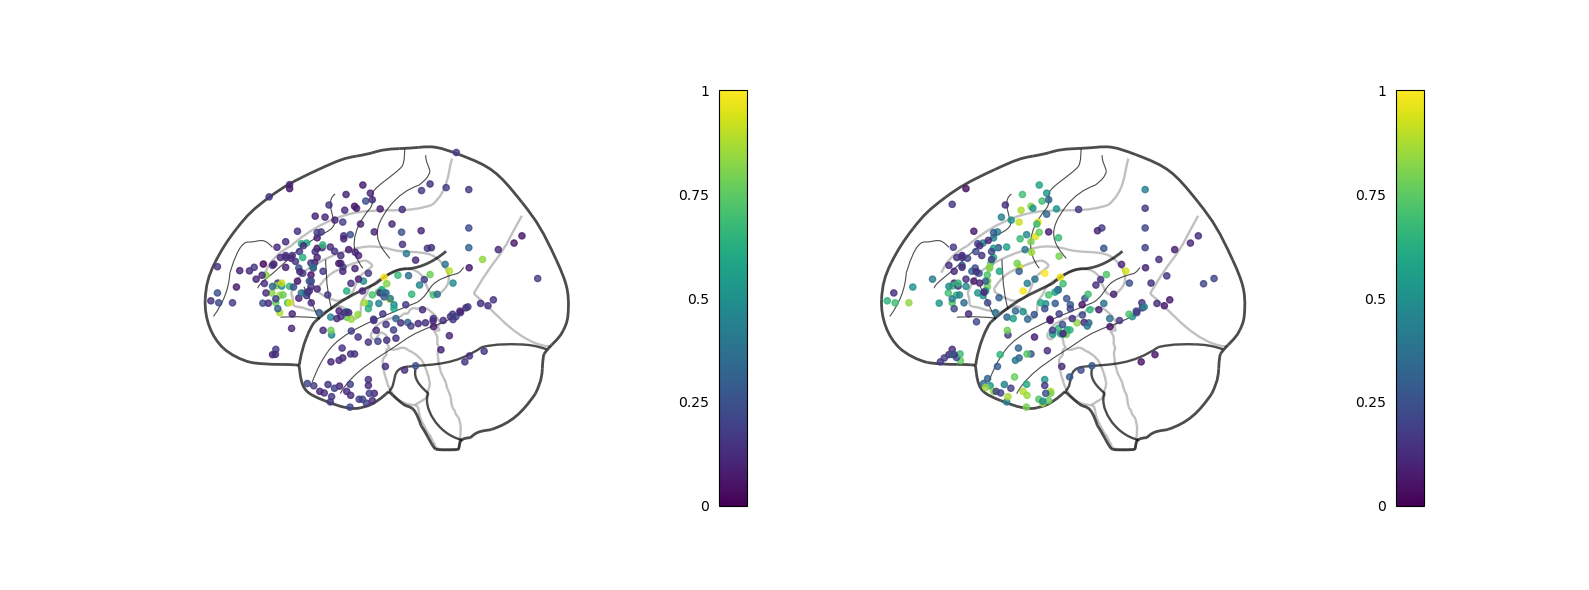

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
cmap = 'viridis'


plot_df = grouped_comp_word.copy()
# drop rows where max_future_ratio is nan
plot_df = plot_df[~plot_df['word_peak_share'].isna()]
plot_effect_glassbrain(plot_df, effect_col="word_peak_share", show=True, ax=axes[0], cmap=cmap, vmax=1)

plot_df = grouped_prod_word.copy()
# drop rows where max_past_ratio is nan
plot_df = plot_df[~plot_df['word_peak_share'].isna()]
plot_effect_glassbrain(plot_df, effect_col="word_peak_share", show=True, ax=axes[1], cmap=cmap, vmax=1)


plt.tight_layout()
plt.show()

/tmp/ipykernel_1316367/2857526644.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


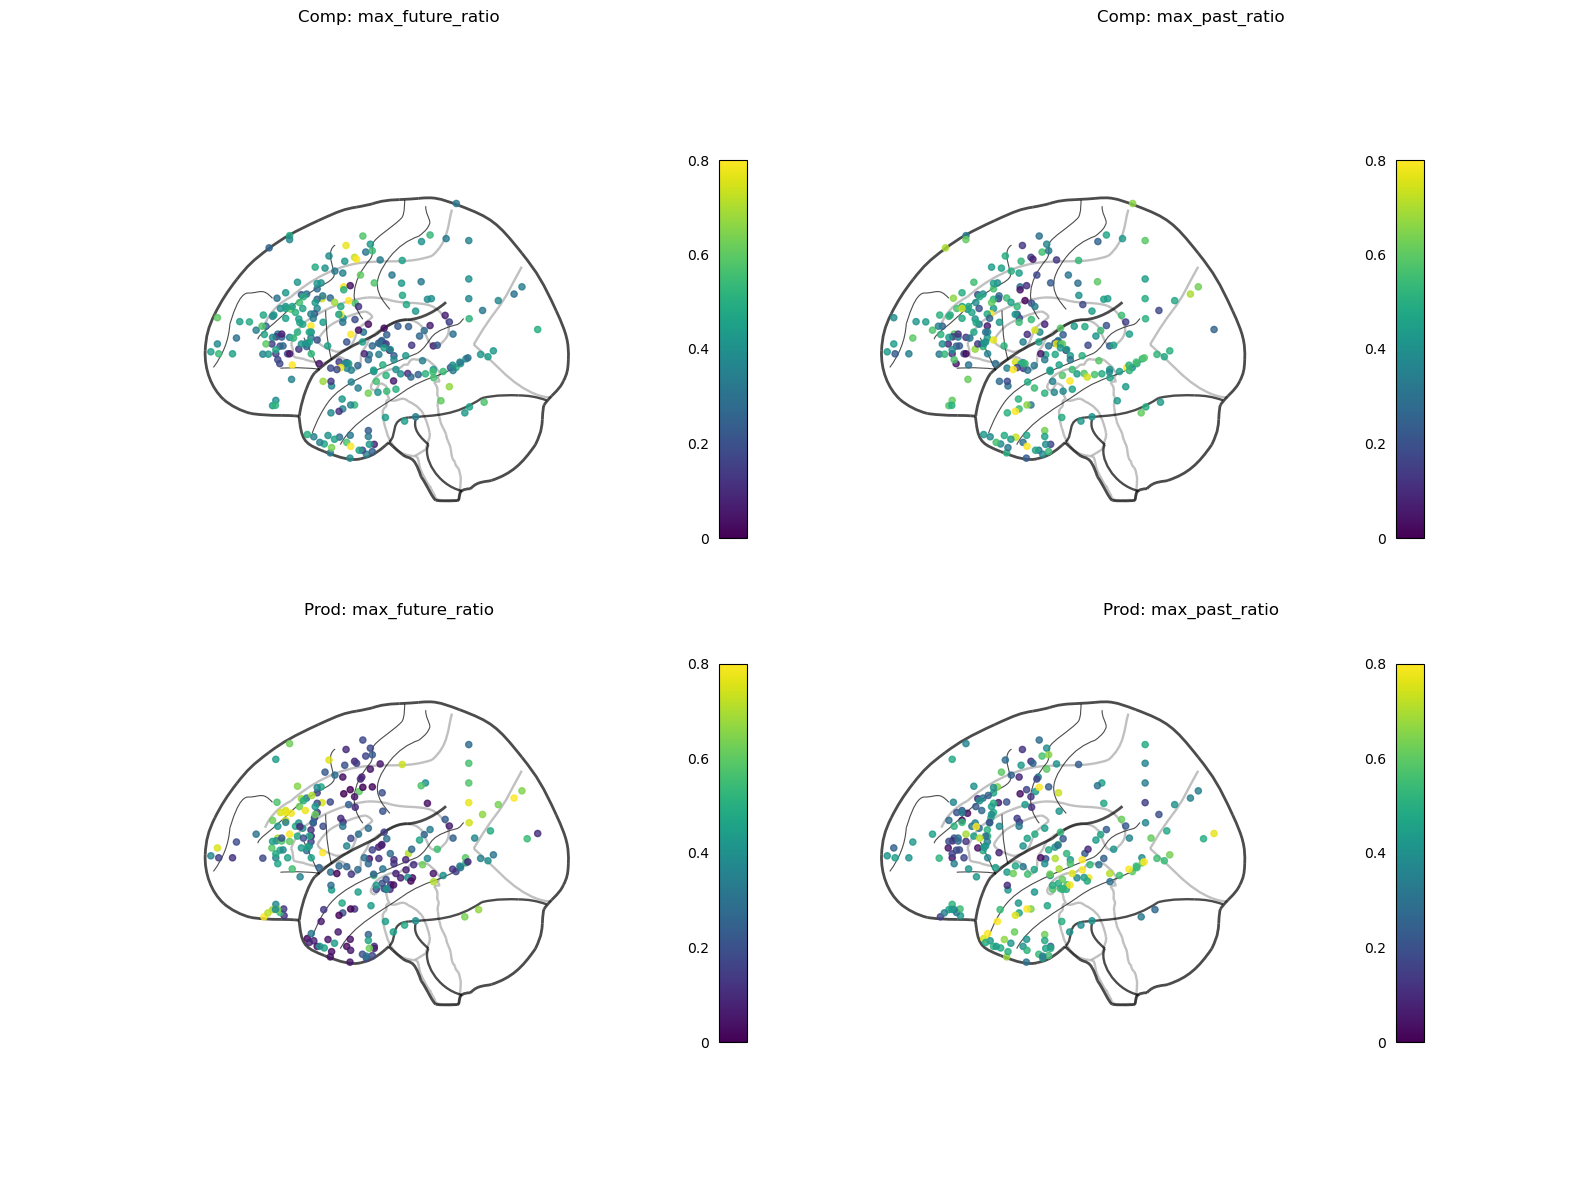

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
cmap = 'viridis'


plot_df = grouped_comp.copy()
# drop rows where max_future_ratio is nan
plot_df = plot_df[~plot_df['max_future_ratio'].isna()]
plot_effect_glassbrain(plot_df, effect_col="max_future_ratio", show=True, ax=axes[0, 0], cmap=cmap, vmax=0.8)
axes[0, 0].set_title("Comp: max_future_ratio")

plot_df = grouped_comp.copy()
# drop rows where max_past_ratio is nan
plot_df = plot_df[~plot_df['max_past_ratio'].isna()]
plot_effect_glassbrain(plot_df, effect_col="max_past_ratio", show=True, ax=axes[0, 1], cmap=cmap, vmax=0.8)
axes[0, 1].set_title("Comp: max_past_ratio")

plot_df = grouped_prod.copy()
# drop rows where max_future_ratio is nan
plot_df = plot_df[~plot_df['max_future_ratio'].isna()]
plot_effect_glassbrain(plot_df, effect_col="max_future_ratio", show=True, ax=axes[1, 0], cmap=cmap, vmax=0.8)
axes[1, 0].set_title("Prod: max_future_ratio")

plot_df = grouped_prod.copy()
# drop rows where max_past_ratio is nan
plot_df = plot_df[~plot_df['max_past_ratio'].isna()]
plot_effect_glassbrain(plot_df, effect_col="max_past_ratio", show=True, ax=axes[1, 1], cmap=cmap, vmax=0.8)
axes[1, 1].set_title("Prod: max_past_ratio")

plt.tight_layout()
plt.show()

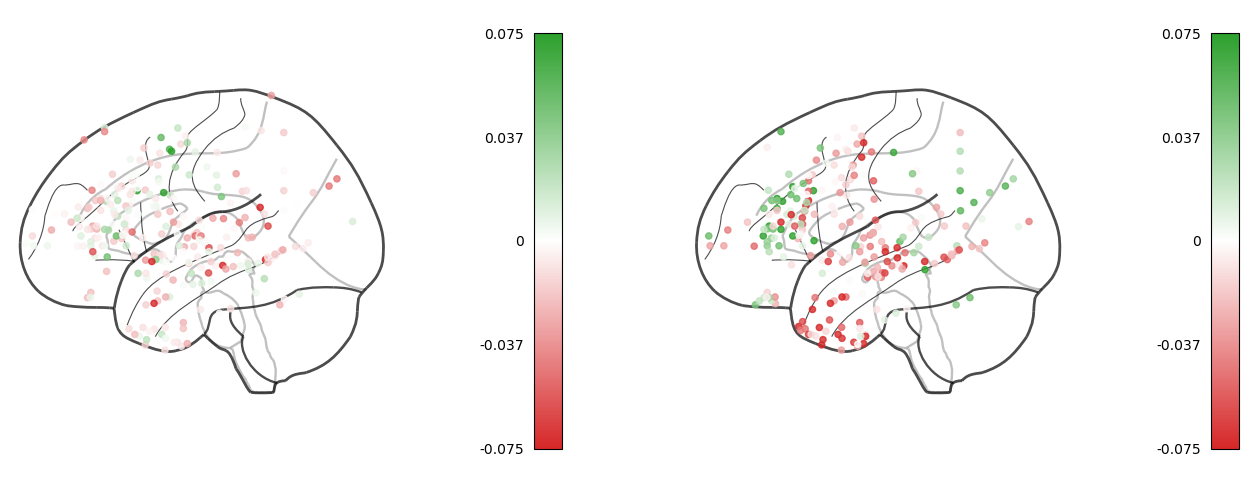

In [32]:
grouped_comp['future_past_diff'] = grouped_comp['max_future_sentence'] - grouped_comp['max_past_sentence2']
grouped_prod['future_past_diff'] = grouped_prod['max_future_sentence'] - grouped_prod['max_past_sentence2']

div_cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "custom_div",
    [args.colors[3], "white", args.colors[2]]
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
cmap = div_cmap


plot_df = grouped_comp.copy()
# drop rows where max_future_ratio is nan
plot_df = plot_df[~plot_df['future_past_diff'].isna()]
plot_effect_glassbrain(plot_df, effect_col="future_past_diff", show=True, ax=axes[0], cmap=cmap, vmin=-0.075, vmax=0.075)

plot_df = grouped_prod.copy()
# drop rows where max_past_ratio is nan
plot_df = plot_df[~plot_df['future_past_diff'].isna()]
plot_effect_glassbrain(plot_df, effect_col="future_past_diff", show=True, ax=axes[1], cmap=cmap, vmin=-0.075, vmax=0.075)


plt.show()
